In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
print('환경 설정 완료!')

환경 설정 완료!


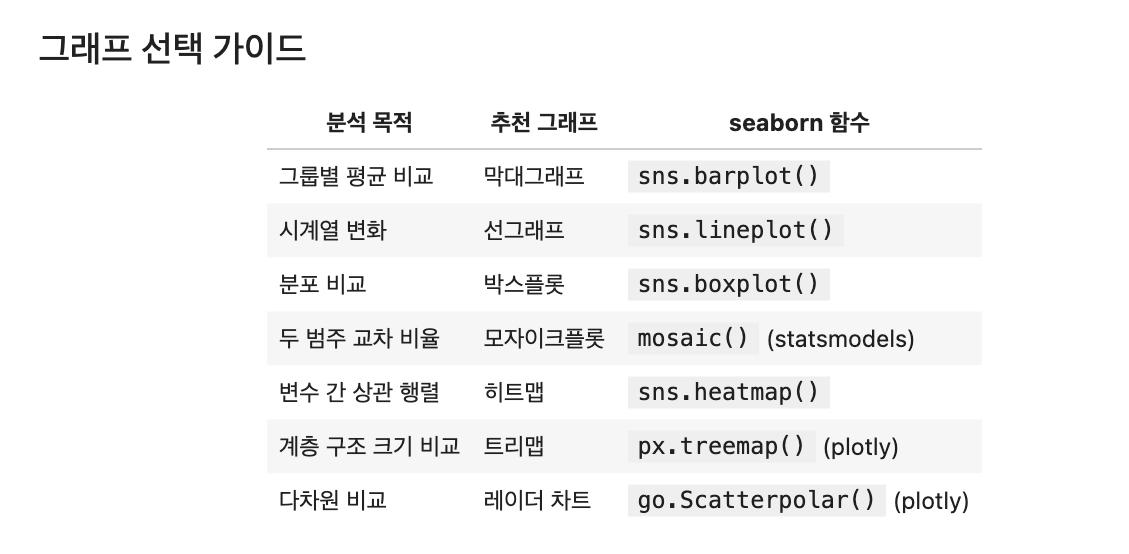

### seaborn = barplot : 범주형 데이터

tips 데이터 앞 3행:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3


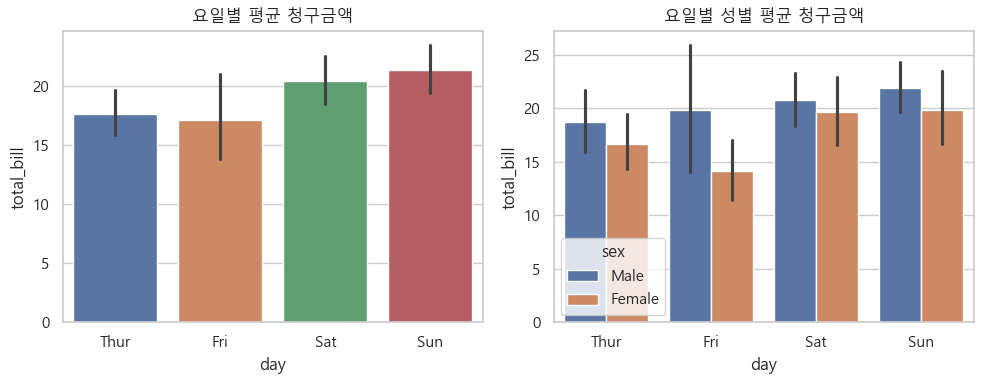

In [4]:
df = sns.load_dataset('tips')
print('tips 데이터 앞 3행:')
print(df.head(3))

sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)}, font='Malgun Gothic')

fig, axes = plt.subplots(1, 2)

# 요일별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='day', legend=False, ax=axes[0])
axes[0].set_title('요일별 평균 청구금액')

# 요일별 성별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='sex', ax=axes[1])
axes[1].set_title('요일별 성별 평균 청구금액')

plt.tight_layout()
plt.show()

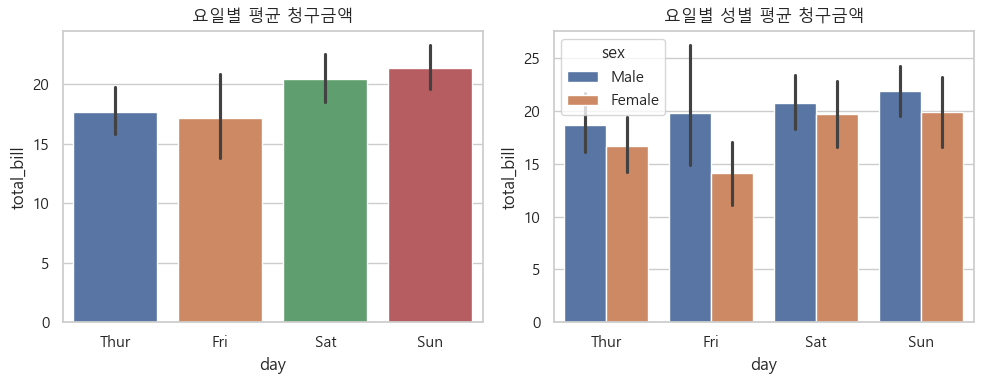

In [6]:
sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)}, font='Malgun Gothic')
# set_theme 실행 시 자체 font 타입으로 리셋되므로 font 형식을 추가해야 함.

fig, axes = plt.subplots(1, 2)

# 요일별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='day', legend=False, ax=axes[0])
axes[0].set_title('요일별 평균 청구금액')

# 요일별 성별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='sex', ax=axes[1])
axes[1].set_title('요일별 성별 평균 청구금액')

plt.tight_layout()
plt.show()

In [7]:
# [실습] seaborn - barplot : 범주형 데이터 : iris 품종별 평균 꽃잎 길이
df_iris = pd.read_csv('data/iris.csv')
df_iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


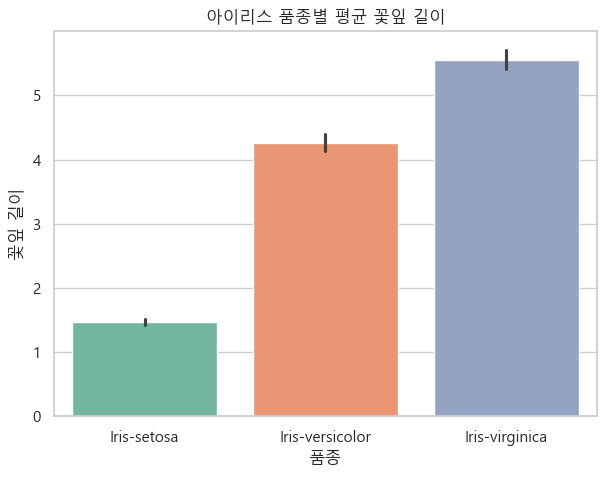

In [22]:
# x : 품종, y : 꽃잎길이

sns.set_theme(style='whitegrid', rc={'figure.figsize': (7, 5)}, font='Malgun Gothic')
# set_theme 실행 시 자체 font 타입으로 리셋되므로 font 형식을 추가해야 함.

sns.barplot(
            data=df_iris, 
            x='Species', 
            y='PetalLengthCm', 
            estimator='mean',
            hue='Species', 
            palette='Set2',
            legend=False
)

plt.title('아이리스 품종별 평균 꽃잎 길이')
plt.xlabel('품종')
plt.ylabel('꽃잎 길이')

plt.show()

## seaborn lineplot - 월별 항공 탑승객

In [24]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


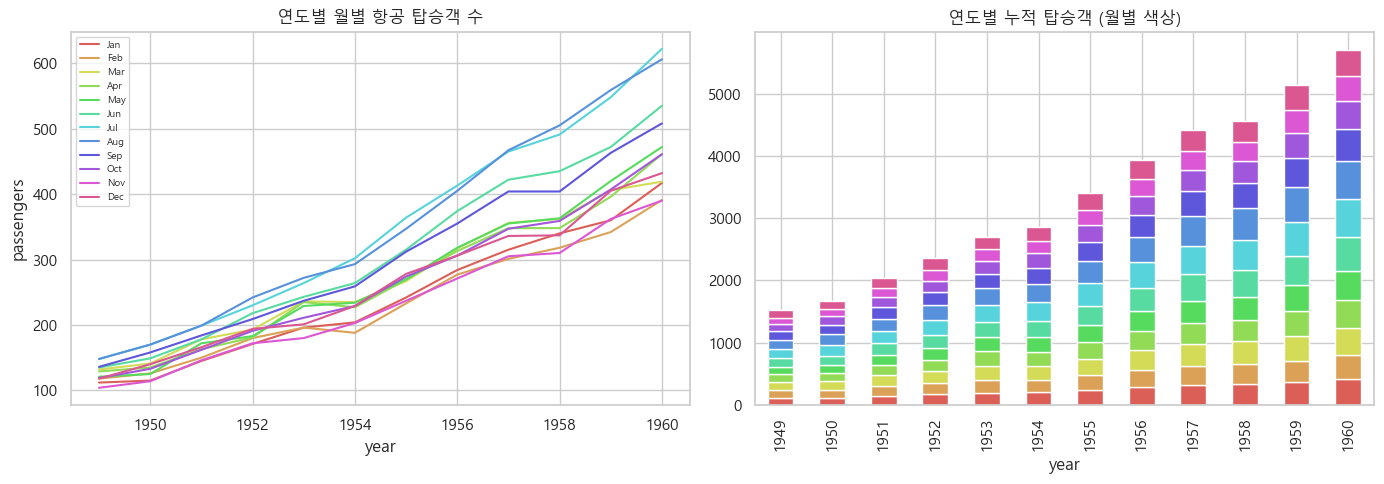

In [23]:
# [예제 2] seaborn lineplot + 누적 막대그래프 (code8_2)
import seaborn as sns
import matplotlib.pyplot as plt

flights = sns.load_dataset('flights')
sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)}, font='Malgun Gothic')
sns.set_palette('hls', 12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 선그래프
sns.lineplot(data=flights, x='year', y='passengers',
             hue='month', ax=axes[0])
axes[0].set_title('연도별 월별 항공 탑승객 수')
axes[0].legend(loc='upper left', fontsize=7)

# 누적 막대그래프
df2 = flights.pivot_table(index='year', columns='month',
                          values='passengers', aggfunc='mean')
df2.plot.bar(stacked=True, ax=axes[1], legend=False)
axes[1].set_title('연도별 누적 탑승객 (월별 색상)')

plt.tight_layout()
plt.show()

### [예제 3] seaborn boxplot — 서울 기온

In [26]:
# 서울 월별 기온 분포 - seaborn boxplot
df = pd.read_csv('data/OBS_ASOS_DD_20250101.csv')
df.head()

,지점,지점명,일시,평균기온(°C)
0,108,서울,2025-01-01,2.6
1,108,서울,2025-01-02,0.5
2,108,서울,2025-01-03,-1.1
3,108,서울,2025-01-04,-0.1
4,108,서울,2025-01-05,1.2


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   지점        181 non-null    int64  
 1   지점명       181 non-null    object 
 2   일시        181 non-null    object 
 3   평균기온(°C)  181 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 5.8+ KB


In [29]:
df['일시'] = pd.to_datetime(df['일시'])
df['일시'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 181 entries, 0 to 180
Series name: 일시
Non-Null Count  Dtype         
--------------  -----         
181 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.5 KB


In [31]:
# '일시' 컬럼을 year, month, day 컬럼으로 분리
df['연도'] = df['일시'].dt.year
df['월'] = df['일시'].dt.month
df['일'] = df['일시'].dt.day
df.head()
df['월'].value_counts()

월
1    31
3    31
5    31
4    30
6    30
2    28
Name: count, dtype: int64